In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
salarios = np.array([10.00, 10.16, 10.31, 10.47, 10.62, 10.77, 10.92, 11.08, 11.24, 11.40,
                     11.56, 11.72, 11.88, 12.03, 12.19, 12.34, 12.50, 12.66, 12.81, 12.96,
                     13.12, 13.27, 13.43, 13.58, 13.73, 13.89, 14.04, 14.19, 14.35, 14.50, 14.66])

prob = np.array([0.1168, 0.1343, 0.1531, 0.1745, 0.1972, 0.2229, 0.2501, 0.2805, 0.3137, 0.3488,
                 0.3860, 0.4243, 0.4634, 0.5020, 0.5417, 0.5793, 0.6167, 0.6530, 0.6872, 0.7192,
                 0.7492, 0.7767, 0.8027, 0.8256, 0.8467, 0.8663, 0.8829, 0.8976, 0.9107, 0.9228, 0.9333])

s0, a, b = 12.50, 10.00, 14.66
print("Datos cargados:", len(salarios), "puntos")

Datos cargados: 31 puntos


In [25]:
# Riemann
def riemann(x, y, modo):
    n = len(x)-1
    return sum(y[i if modo=='izq' else i+1] * (x[i+1]-x[i]) for i in range(n))

# Trapecio
def trapecio(x, y):
    return sum((y[i]+y[i+1])*(x[i+1]-x[i])/2 for i in range(len(x)-1))

# Integral exacta sigmoide
def exacta(a, b, s0):
    return np.log((1+np.exp(b-s0))/(1+np.exp(a-s0)))

# Integral Taylor
def taylor(a, b, s0):
    p0, dp = 0.6167, 0.2409
    F = lambda s: p0*s + dp*(s**2/2 - s0*s)
    return F(b) - F(a)

In [26]:
I_riem_izq = riemann(salarios, prob, 'izq')
I_riem_der = riemann(salarios, prob, 'der')
I_trap = trapecio(salarios, prob)
I_exac = exacta(a, b, s0)
I_tayl = taylor(a, b, s0)

print("\n" + "="*50)
print("RESULTADOS")
print("="*50)
print(f"Riemann izquierda: {I_riem_izq:.6f}")
print(f"Riemann derecha:   {I_riem_der:.6f}")
print(f"Trapecio:          {I_trap:.6f}")
print(f"Exacta (sigmoide): {I_exac:.6f}")
print(f"Taylor:            {I_tayl:.6f}")
print("="*50)


RESULTADOS
Riemann izquierda: 2.518228
Riemann derecha:   2.645351
Trapecio:          2.581789
Exacta (sigmoide): 2.190256
Taylor:            2.682981


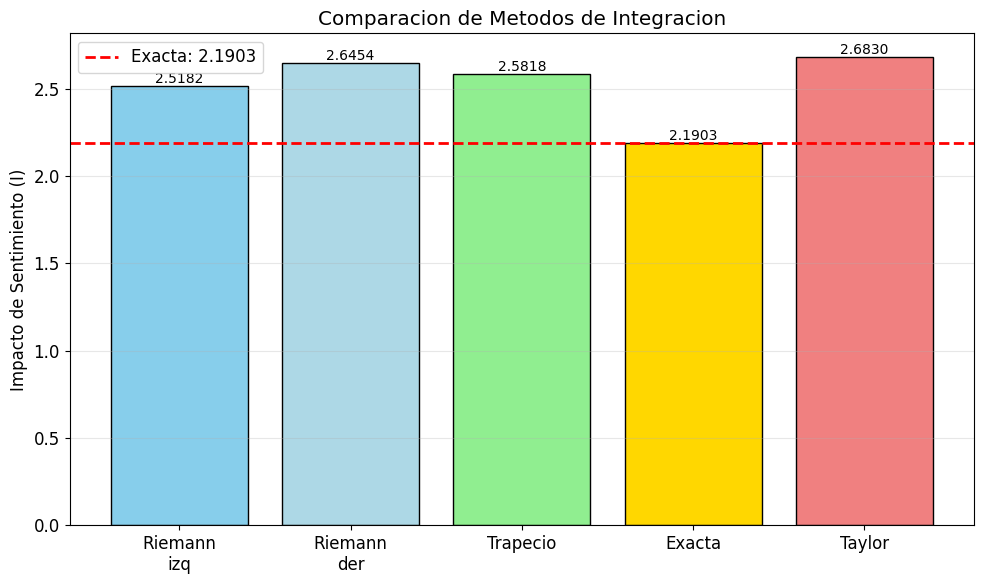

In [27]:
# Preparar datos para la grafica
metodos = ['Riemann\nizq', 'Riemann\nder', 'Trapecio', 'Exacta', 'Taylor']
valores = [I_riem_izq, I_riem_der, I_trap, I_exac, I_tayl]
colores = ['skyblue', 'lightblue', 'lightgreen', 'gold', 'lightcoral']

# Crear grafica
plt.figure(figsize=(10, 6))
barras = plt.bar(metodos, valores, color=colores, edgecolor='black', linewidth=1)

# Linea del valor exacto
plt.axhline(y=I_exac, color='red', linestyle='--', linewidth=2,
            label=f'Exacta: {I_exac:.4f}')

# Valores sobre las barras
for barra, val in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.ylabel('Impacto de Sentimiento (I)')
plt.title('Comparacion de Metodos de Integracion')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [28]:
print("\n" + "="*50)
print("ERRORES RESPECTO AL VALOR EXACTO")
print("="*50)
print(f"{'Metodo':<15} {'Diferencia':<12} {'Error %':<10}")
print("-"*50)

for nombre, valor in zip(['Riemann izq', 'Riemann der', 'Trapecio', 'Taylor'],
                          [I_riem_izq, I_riem_der, I_trap, I_tayl]):
    diff = valor - I_exac
    error = abs(diff)/I_exac*100
    print(f"{nombre:<15} {diff:<+12.6f} {error:<10.2f}%")
print("="*50)


ERRORES RESPECTO AL VALOR EXACTO
Metodo          Diferencia   Error %   
--------------------------------------------------
Riemann izq     +0.327972    14.97     %
Riemann der     +0.455095    20.78     %
Trapecio        +0.391533    17.88     %
Taylor          +0.492725    22.50     %
